<a href="https://colab.research.google.com/github/pachterlab/tcia-ct-processing-protocol/blob/main/tcga_ct_processing_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    import tcia_radiology_processing
except ImportError:
    print("tcia_radiology_processing not found, installing...")
    # !pip install -q git+https://github.com/pachterlab/tcia-radiology-processing.git

# Processing TCIA CT data from TCGA for AI/radiomics analysis

In [ ]:
import os
import sys
import shutil
import subprocess
import pydicom
import pandas as pd
from tqdm import tqdm
import yaml
from IPython.display import Image, display
from tcia_radiology_processing import utils

from IPython.core.magic import register_cell_magic
from IPython import get_ipython

@register_cell_magic
def skip_if(line, cell):
    if eval(line):
        return
    get_ipython().run_cell(cell)

base_directory = os.path.dirname(os.path.abspath(""))

# import importlib
# import tcia_radiology_processing.utils as utils
# importlib.reload(utils)

# Define hyperparameters

In [ ]:
dataset = "tcga-lihc"  #!!! tcga-kirc
data_dir = f"/mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/{dataset}/imaging"  #!!! os.path.join(base_directory, "data", "radiogenomics", "tcga", dataset, "imaging")
nbia_data_retriever = "nbia-data-retriever"  # path to nbia-data-retriever executable
num_series = None  # number of series to keep - set to None for all series
using_usc_data = True
image_dimensionality = "3D"  # "2D" or "3D"
do_radiomics = False
do_masking = True
interactive = False  # whether to display images interactively during processing

# processing settings
orient = True
clip = True
resample = True  # True if not do_radiomics else False  # handled inside params yaml file for radiomics
# do_masking = do_masking if not do_radiomics else False
mask_value_for_best_slice_selection = 2  # use tumor if available, otherwise use organs (will switch later if needed)
mask_values = None  # 1 for organ, 2 for tumor, None for all > 0
# standardize_dimensions = True if not do_radiomics else False
normalize = False  # True if not do_radiomics else False  # handled inside params yaml file for radiomics
normalization_method = "volume"

# radiomics settings
resampledPixelSpacing = [1, 1, 1] if image_dimensionality == "3D" else [1, 1]
pyradiomics_param = {
    "imageType": {
        "Original": {}
    },
    "setting": {
        "binWidth": 25,
        "resampledPixelSpacing": resampledPixelSpacing,
        "interpolator": "sitkBSpline",
        "normalize": False,
        "padDistance": 5
    }
}

# leave as-is
utils.PROFILE_PIPELINE_DATA_DIR = None  # None to skip measuring storage, data_dir to measure storage (takes 1-3s per measurement, so only set if you want to measure storage)

# Data download

In [ ]:
tcia_dataset_to_info = {
    "tcga-kirc": {  # kidney renal clear cell carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["kidney_left", "kidney_right"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
        "xdim,ydim,zdim": (185, 185, 75) if do_masking else (625, 625, 200)  # dimensions to standardize to - set to (None, None, None) to use 95th percentile of extents across all series
    },
    "tcga-lihc": {  # liver hepatocellular carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": "https://www.cancerimagingarchive.net/wp-content/uploads/doiJNLP-TCGA-LIHC-01-30-2017-nbia-digest.xlsx",  # None for default
        "totalsegmentator_organs": ["liver"],
        "clip_min,clip_max": (-200, 400),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-blca": {  # bladder urothelial carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCGA-BLCA-August-30-2019-NBIA-manifes-nbia-digest.xlsx",  # None for default
        "totalsegmentator_organs": ["urinary_bladder"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    # "tcga-brca": {  # breast invasive carcinoma - all XRs
    #     "manifest_url": None,  # None for default
    #     "metadata_url": None,  # None for default
    #     "totalsegmentator_organs": ["breasts"],
    #     "totalsegmentator_task": "breasts",  # None/omit for total
    #     "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    # },
    "tcga-cesc": {  # cervical squamous cell carcinoma and endocervical adenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": [],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-coad": {  # colon adenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["colon"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-esca": {  # esophageal carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["esophagus"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-gbm": {  # glioblastoma multiforme
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["brain"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-hnsc": {  # head and neck squamous cell carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["skull"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-kich": {  # kidney renal papillary cell carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["kidney_left", "kidney_right"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-kirp": {  # kidney renal clear cell carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["kidney_left", "kidney_right"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-lgg": {  # brain lower grade glioma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["brain"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-luad": {  # lung adenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["lung_upper_lobe_left", "lung_lower_lobe_left", "lung_upper_lobe_right", "lung_middle_lobe_right", "lung_lower_lobe_right"],
        "clip_min,clip_max": (-1000, 400),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-lusc": {  # lung squamous cell carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["lung_upper_lobe_left", "lung_lower_lobe_left", "lung_upper_lobe_right", "lung_middle_lobe_right", "lung_lower_lobe_right"],
        "clip_min,clip_max": (-1000, 400),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-ov": {  # ovarian serous cystadenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": [],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-prad": {  # prostate adenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["prostate"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-read": {  # rectum adenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["colon"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-stad": {  # stomach adenocarcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": ["stomach"],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    "tcga-ucec": {  # uterine corpus endometrial carcinoma
        "manifest_url": None,  # None for default
        "metadata_url": None,  # None for default
        "totalsegmentator_organs": [],
        "clip_min,clip_max": (-200, 300),  # (min, max) to clip pixel values to before resampling and feature extraction - set to (None, None) for no clipping
    },
    # add more datasets here as needed
}

if dataset not in tcia_dataset_to_info:
    raise ValueError(f"Dataset {dataset} not recognized. Please add it to tcia_dataset_to_info.")
if tcia_dataset_to_info[dataset]["totalsegmentator_organs"] is None or len(tcia_dataset_to_info[dataset]["totalsegmentator_organs"]) == 0:
    raise ValueError(f"Totalsegmentator organs not specified for dataset {dataset}. Please specify the organs to segment for this dataset in tcia_dataset_to_info.")
if dataset != "tcga-kirc":
    using_usc_data = False  # only tcga-kirc has USC data available, so set to False for other datasets

clip_min, clip_max = tcia_dataset_to_info[dataset].get("clip_min,clip_max", (None, None))
xdim, ydim, zdim = tcia_dataset_to_info[dataset].get("xdim,ydim,zdim", (None, None, None))

## Metadata

In [ ]:
%%skip_if using_usc_data

metadata_name = f"metadata_{num_series}.csv" if num_series is not None else "metadata.csv"
imaging_metadata_csv = os.path.join(data_dir, metadata_name)

if not os.path.exists(imaging_metadata_csv):
    imaging_metadata_csv_dir = os.path.dirname(imaging_metadata_csv) if os.path.dirname(imaging_metadata_csv) != "" else "."
    metadata_url = tcia_dataset_to_info[dataset].get("metadata_url") or f"https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_{dataset.upper()}_09-16-2015-nbia-digest.xlsx"
    additional_metadata_file_name = metadata_url.split("/")[-1]
    additional_metadata_xlsx = os.path.join(imaging_metadata_csv_dir, additional_metadata_file_name)

    os.makedirs(imaging_metadata_csv_dir, exist_ok=True)
    if not os.path.exists(additional_metadata_xlsx):
        subprocess.run(["wget", "-O", additional_metadata_xlsx, metadata_url], check=True)
    
    # add short patient ID
    imaging_metadata_df = pd.read_excel(additional_metadata_xlsx)
    imaging_metadata_df.insert(0, "series_id", [f"series_{i:05d}" for i in range(len(imaging_metadata_df))])
    
    # change column names to match old format
    col_renames = {
        "Series Instance UID": "Series UID",
        "Study Instance UID": "study_id",
        "Patient ID": "patient_id",
        "Image Count": "Number of Images Original",
    }
    imaging_metadata_df.rename(columns=col_renames, inplace=True)
    imaging_metadata_df.to_csv(imaging_metadata_csv, index=False)

metadata_df = pd.read_csv(imaging_metadata_csv)

In [ ]:
%%skip_if using_usc_data

print(f"Number of imaging series in metadata: {len(metadata_df)}")
metadata_df.head()

In [52]:
%%skip_if using_usc_data

metadata_df["ParsedRegion"] = metadata_df["Study Description"].apply(utils.categorize_region_tcga)
if dataset == "tcga-kirc":
    metadata_df["Phase"] = metadata_df["Series Description"].apply(utils.categorize_phase)
utils.print_tcia_info(metadata_df, project=dataset)

=== TOTALS ===
Total series:   1688
Total studies:  237
Total patients: 97

=== BY MODALITY ===
          num_series  num_studies  num_patients
Modality                                       
MR               910           73            40
CT               777          164            75
PT                 1            1             1

=== BY MODALITY + REGION ===
                               num_series  num_studies  num_patients
Modality ParsedRegion                                               
CT       Abdomen                      427           80            48
         Abdomen/Pelvis               134           44            30
         Chest                        122           21            18
         Chest/Abdomen/Pelvis          43            8             8
         Other                         43            9             9
         Unknown                        5            1             1
         Pelvis                         3            1             1
MR       Abdo

## Imaging data

In [ ]:
%%skip_if using_usc_data

manifest_url = tcia_dataset_to_info[dataset].get("manifest_url") or f"https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_{dataset.upper()}_09-16-2015.tcia"
manifest_file_name = manifest_url.split("/")[-1]
manifest_file_path = os.path.join(data_dir, manifest_file_name)

if not os.path.exists(manifest_file_path):
    subprocess.run(f"wget {manifest_url} -P {data_dir}", shell=True, check=True)
if num_series is not None:
    manifest_file_path_subset_series = manifest_file_path.replace(".tcia", f"_subset_{num_series}.tcia")
    if not os.path.exists(manifest_file_path_subset_series):
        with open(manifest_file_path, "r") as f_in, open(manifest_file_path_subset_series, "w") as f_out:
            num_lines = num_series + 6  # 6 header lines in manifest file
            for i, line in enumerate(f_in):
                if i >= num_lines:
                    break
                f_out.write(line)
    manifest_file_path = manifest_file_path_subset_series
    manifest_file_name = manifest_file_path.split("/")[-1]
    series_uids = utils.get_series_uids_from_manifest(manifest_file_path)
    metadata_df = metadata_df[metadata_df["Series UID"].isin(series_uids)]

metadata_df.head()

In [ ]:
%%skip_if using_usc_data

image_dir = os.path.join(data_dir, manifest_file_name.split(".")[0], dataset.upper())
if shutil.which(nbia_data_retriever) is None:
    sys.exit(f"Error: {nbia_data_retriever} not found in PATH. Please install or add it to PATH.")

nbia_command = f"yes 'Y\nM' | {nbia_data_retriever} --cli {manifest_file_path} -d {data_dir} -v -f"
print(f"Running NBIA Data Retriever with command:\n{nbia_command}")
subprocess.run(nbia_command, shell=True, check=True)

print(f"Downloaded images to: {image_dir}")

### View imaging data

In [ ]:
%%skip_if using_usc_data

!tree {image_dir} -P "1-1.dcm|1-01.dcm|01-01.dcm|1-001.dcm"

In [ ]:
%%skip_if using_usc_data

first_dir = next(f for f in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, f)))
image_subdir = os.path.join(image_dir, first_dir)

sample_dcm_file = subprocess.check_output(
    f'find {image_subdir} -type f -name "*.dcm" | sort | head -n 1',
    shell=True
).decode().strip()
sample_dcm_dir = os.path.dirname(sample_dcm_file)

dcm = pydicom.dcmread(sample_dcm_file, stop_before_pixels=True)
uid = dcm.SeriesInstanceUID

print(sample_dcm_file)
print(uid)

In [ ]:
%%skip_if using_usc_data

utils.view_dicom(sample_dcm_file)

In [ ]:
%%skip_if using_usc_data or not interactive

utils.view_dicom(sample_dcm_dir)

### Add acquisition time data for kidney

In [ ]:
# if dataset == "tcga-kirc":
#     metadata_df = utils.update_phase_column_with_acquisition_time(metadata_df, image_dir)
#     metadata_df.head()

# Data filtering

In [ ]:
%%skip_if using_usc_data

metadata_df = utils.add_viable_info(image_subdir, metadata_df, min_files=5, max_thickness_mm=10, include_kernel_keywords=True, out=imaging_metadata_csv, overwrite=True)
metadata_df[["series_id", "Series UID", "is_viable", "viable_reason"]].head()

In [ ]:
%%skip_if using_usc_data

metadata_df = metadata_df[metadata_df["is_viable"]]
metadata_df = metadata_df[metadata_df["Modality"] == "CT"]
utils.print_tcia_info(metadata_df, project=dataset)
metadata_df.head()

# DICOM to NIfTI

In [ ]:
%%skip_if using_usc_data

image_filename = "imaging.nii.gz"
tumor_mask_filename = None
nifti_dir_name = f"nifti_{num_series}" if num_series is not None else "nifti"
nifti_dir = os.path.join(data_dir, nifti_dir_name)

# if not os.path.exists(nifti_dir) or len(os.listdir(nifti_dir)) == 0:
utils.convert_dcm_to_nii_and_organize(image_dir, metadata_df, nifti_dir, segimage2itkimage_conda=False)
print(f"convert_dcm_to_nii_and_organize metrics: {utils.convert_dcm_to_nii_and_organize.last_metrics}")

In [ ]:
%%skip_if using_usc_data

# filter out 4D volumes and niis with big max zoom (sometimes some series will have an axial localizer but an otherwise coronal/sagittal series - we want to exclude these)
metadata_df = utils.check_and_delete_bad_niftis(metadata_df, nifti_dir, image_filename=image_filename, is_4d=True, max_zoom_maximum=20)
utils.print_tcia_info(metadata_df, project=dataset)
metadata_df.head()

In [57]:
if using_usc_data and dataset == "tcga-kirc":
    metadata_name = f"metadata_usc_{num_series}.csv" if num_series is not None else "metadata_usc.csv"
    imaging_metadata_csv = os.path.join(data_dir, metadata_name)
    
    nifti_dir_name = f"nifti_usc_{num_series}" if num_series is not None else "nifti_usc"
    nifti_dir = os.path.join(data_dir, nifti_dir_name)
    
    image_filename = "0502_VENOUS.nii"
    tumor_mask_filename = "segmentation_tumor.nii.gz"

    if not os.path.exists(nifti_dir) or len(os.listdir(nifti_dir)) == 0:
        _ = utils.download_usc_tcga_kirc_data(data_dir, imaging_metadata_csv=imaging_metadata_csv, num_series=num_series, dst_dir_name=nifti_dir_name)

    metadata_df = pd.read_csv(imaging_metadata_csv)

In [ ]:
!tree -L 2 {nifti_dir}

In [58]:
series_id_for_sample_uid = metadata_df["series_id"].iloc[0]  # metadata_df[metadata_df["Series UID"] == uid].iloc[0]["series_id"]
sample_nii_dir = os.path.join(nifti_dir, series_id_for_sample_uid)
sample_nii_file = os.path.join(sample_nii_dir, image_filename)

print(sample_nii_file)

/mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00002/imaging.nii.gz


In [62]:
sample_nii_file

'/mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00002/imaging.nii.gz'

INFO:tcia_radiology_processing.utils:Viewing NIfTI file: /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00002/imaging.nii.gz


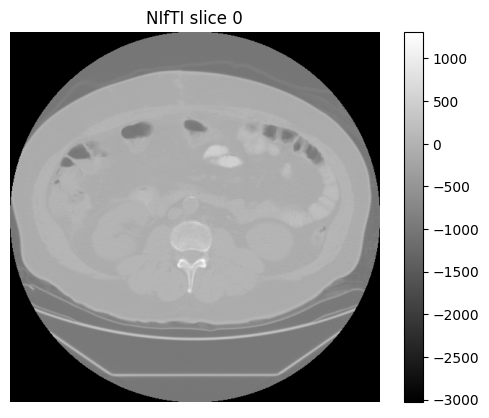

In [59]:
utils.view_nifti(sample_nii_file, z=0)

In [60]:
%%skip_if not interactive

utils.view_nifti(sample_nii_file)

# Orientation

In [61]:
# orient = True

if orient:
    oriented_image_files, oriented_mask_files, final_image_files, final_mask_files = [], [], [], []
    orient_metrics = None
    for series_id in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
        series_dir = os.path.join(nifti_dir, series_id)
        image_file = os.path.join(series_dir, image_filename)
        mask_file = os.path.join(series_dir, tumor_mask_filename) if tumor_mask_filename else ""
        if not os.path.exists(image_file):
            print(f"Image file not found for series_id {series_id} at {image_file}. Skipping.")
            continue

        if orient:
            image_file = utils.set_canonical_orientation(image_file, out=True)
            oriented_image_files.append(image_file)
            orient_metrics = utils.add_metrics(total=orient_metrics, metrics=utils.set_canonical_orientation.last_metrics)
            print(f"Set canonical orientation for image file for series_id {series_id} at {image_file}.")
            if os.path.exists(mask_file):
                mask_file = utils.set_canonical_orientation(mask_file, out=True)
                oriented_mask_files.append(mask_file)
                orient_metrics = utils.add_metrics(total=orient_metrics, metrics=utils.set_canonical_orientation.last_metrics)
        
        final_image_files.append(image_file)
        final_mask_files.append(mask_file)

    image_filename_set = set([os.path.basename(f) for f in final_image_files])
    assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
    image_filename = list(image_filename_set)[0]
    tumor_mask_filename = os.path.basename(final_mask_files[0]) if final_mask_files else ""

    print(f"Orientation metrics: {orient_metrics}")

Processing images:   0%|          | 2/931 [00:00<02:20,  6.62it/s]

Set canonical orientation for image file for series_id series_00002 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00002/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_00005 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00005/imaging_oriented.nii.gz.


Processing images:   0%|          | 4/931 [00:00<02:16,  6.79it/s]

Set canonical orientation for image file for series_id series_00007 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00007/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_00008 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_00008/imaging_oriented.nii.gz.


Processing images:   1%|          | 6/931 [00:00<02:13,  6.95it/s]

...

Set canonical orientation for image file for series_id series_01339 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01339/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_01341 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01341/imaging_oriented.nii.gz.


Processing images: 100%|█████████▉| 927/931 [01:11<00:00,  9.19it/s]

Set canonical orientation for image file for series_id series_01342 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01342/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_01343 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01343/imaging_oriented.nii.gz.


Processing images: 100%|██████████| 931/931 [01:11<00:00, 13.01it/s]

Set canonical orientation for image file for series_id series_01344 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01344/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_01345 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01345/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_01346 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01346/imaging_oriented.nii.gz.
Set canonical orientation for image file for series_id series_01349 at /mnt/gpussd2/jrich/data/radiogenomics_mar26/tcga/tcga-lihc/imaging/nifti/series_01349/imaging_oriented.nii.gz.
Orientation metrics: {'time': 70.58950138092041, 'peak_mem': 1.0488832, 'disk': 0}


In [ ]:
if orient:
    utils.view_nifti(oriented_image_files[0], z=0)

# Organ and tumor segmentation

## Tumor segmentation

In [ ]:
#!!! fill this in
# tumor_mask_filename = "segmentation_tumor.nii.gz"

In [ ]:
if tumor_mask_filename is None and mask_value_for_best_slice_selection == 2:
    mask_value_for_best_slice_selection = 1

## Organ segmentation with TotalSegmentator
Whether to do clipping and resampling before or after organ segmentation depends on the specific segmentation pipeline

In [ ]:
combined_organ_mask_filename = "segmentation_organs.nii.gz"
mask_filename = "segmentation.nii.gz"  # tumor + organs

utils.run_totalsegmentator(nifti_dir, selected_segmentations=tcia_dataset_to_info[dataset]["totalsegmentator_organs"], metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, remove_small_blobs=True, fill_holes=True, morphological_closing=True, image_filename=image_filename, tumor_mask_filename=tumor_mask_filename, combined_organ_mask_filename=combined_organ_mask_filename, mask_filename_out=mask_filename, visualize=False, task=tcia_dataset_to_info[dataset].get("totalsegmentator_task", "total"))
metadata_df = pd.read_csv(imaging_metadata_csv)
print(f"run_totalsegmentator metrics: {utils.run_totalsegmentator.last_metrics}")

In [ ]:
%%skip_if not interactive

sample_nii_mask_file = os.path.join(sample_nii_dir, mask_filename)
utils.view_nifti(sample_nii_mask_file)

In [ ]:
sample_totalsegmentator_visualization_dir = os.path.join(sample_nii_dir, "totalsegmentator", "visualization")
if os.path.exists(sample_totalsegmentator_visualization_dir):
    sample_totalsegmentator_visualization_file = None
    for file in os.listdir(sample_totalsegmentator_visualization_dir):
        if file.endswith("_K.png"):
            sample_totalsegmentator_visualization_file = os.path.join(sample_totalsegmentator_visualization_dir, file)
            break
    if sample_totalsegmentator_visualization_file:
        display(Image(filename=sample_totalsegmentator_visualization_file))
    else:
        print(f"No visualization file with organ found in {sample_totalsegmentator_visualization_dir}")

# Clipping, resampling, slice selection (optional), and masking (with crop to mask)

In [ ]:
# clip = True
resample = True if not do_radiomics else False  # handled inside params yaml file for radiomics
do_masking = do_masking if not do_radiomics else False
# mask_value_for_best_slice_selection = mask_value_for_best_slice_selection if tumor_mask_filename else 1  # use tumor if available, otherwise use organs
# mask_values = None  # 1 for organ, 2 for tumor, None for all > 0

if clip or resample or image_dimensionality == "2D" or do_masking:
    slice_info_list = []
    clipped_image_files, resampled_image_files, resampled_mask_files, slice_image_files, slice_mask_files, masked_image_files, masked_mask_files, final_image_files, final_mask_files = [], [], [], [], [], [], [], [], []
    clip_metrics, resample_metrics, slice_selection_metrics, masking_metrics = None, None, None, None
    for series_id in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
        series_dir = os.path.join(nifti_dir, series_id)
        image_file = os.path.join(series_dir, image_filename)
        mask_file = os.path.join(series_dir, mask_filename) if mask_filename else ""
        if not os.path.exists(image_file):
            print(f"Image file not found for series_id {series_id} at {image_file}. Skipping.")
            continue
        
        if clip:
            if clip_min is None and clip_max is None:  # eg (-200, 300) for soft tissue window - done in training loop
                raise ValueError(f"clip_min and clip_max cannot both be None if clip is True. Got clip_min={clip_min}, clip_max={clip_max}.")
            print(f"Clipping intensity range for image file for series_id {series_id} at {image_file} with clip_min={clip_min}, clip_max={clip_max}.")
            image_file = utils.clip_intensity_range(image_file, clip_min=clip_min, clip_max=clip_max, out=True)
            clipped_image_files.append(image_file)
            print(f"Clipped intensity range for image file for series_id {series_id} at {image_file} with clip_min={clip_min}, clip_max={clip_max}.")
            clip_metrics = utils.add_metrics(total=clip_metrics, metrics=utils.clip_intensity_range.last_metrics)

        if resample:
            image_file = utils.resample_image(image_file, target_spacing=(0.8, 0.8, 3.0), is_label=False, out=True)
            resampled_image_files.append(image_file)
            print(f"Resampled image file for series_id {series_id} at {image_file}.")
            resample_metrics = utils.add_metrics(total=resample_metrics, metrics=utils.resample_image.last_metrics)
            if os.path.exists(mask_file):
                mask_file = utils.resample_image(mask_file, target_spacing=(0.8, 0.8, 3.0), is_label=True, out=True)
                resampled_mask_files.append(mask_file)
                resample_metrics = utils.add_metrics(total=resample_metrics, metrics=utils.resample_image.last_metrics)
        
        if image_dimensionality == "2D":
            if not os.path.exists(mask_file):
                raise ValueError(f"Mask file not found for series_id {series_id} at {mask_file}. Cannot select slice with most mask without mask file.")

            image_file, mask_file, slice_info = utils.choose_slice_with_most_mask_single_image(image=image_file, mask=mask_file, mask_value=mask_value_for_best_slice_selection, out_image=True, out_mask=True)
            slice_image_files.append(image_file)
            slice_mask_files.append(mask_file)
            slice_info["series_id"] = series_id
            slice_info_list.append(slice_info)
            slice_selection_metrics = utils.add_metrics(total=slice_selection_metrics, metrics=utils.choose_slice_with_most_mask_single_image.last_metrics)
        
        if do_masking and os.path.exists(mask_file):
            image_file, mask_file = utils.apply_mask(image_file, mask_file, label=mask_values, min_value=clip_min, crop=True, pad_after_crop=5, out_image=True, out_mask=True)
            masked_image_files.append(image_file)
            masked_mask_files.append(mask_file)
            masking_metrics = utils.add_metrics(total=masking_metrics, metrics=utils.apply_mask.last_metrics)
            print(f"Applied masking to image file for series_id {series_id} at {image_file} using mask file at {mask_file} with mask values {mask_values}.")

        final_image_files.append(image_file)
        if mask_filename:
            final_mask_files.append(mask_file)

    image_filename_set = set([os.path.basename(f) for f in final_image_files])
    assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
    image_filename = list(image_filename_set)[0]

    if mask_filename:
        mask_filename_set = set([os.path.basename(f) for f in final_mask_files if f])  # filter out empty mask files
        assert len(mask_filename_set) <= 1, f"Expected all mask files to have the same filename, but found: {mask_filename_set}"
        mask_filename = list(mask_filename_set)[0] if mask_filename_set else ""
    
    if slice_info_list:
        slice_info_df = pd.DataFrame(slice_info_list)
        if len(slice_info_df.columns) > 1:  # ie has a column other than series_id
            slice_info_df_columns = list(slice_info_df.columns)
            for col in slice_info_df_columns:
                if col in metadata_df.columns and col != "series_id":
                    # metadata_df.drop(columns=[col], inplace=True)  # replace with new value
                    slice_info_df.drop(columns=[col], inplace=True)  # keep old value
            
            metadata_df = metadata_df.merge(slice_info_df, on="series_id", how="left")
    
    print(f"clip_metrics: {clip_metrics}")
    print(f"resample_metrics: {resample_metrics}")
    print(f"slice_selection_metrics: {slice_selection_metrics}")
    print(f"masking_metrics: {masking_metrics}")

In [ ]:
if clip:
    utils.view_nifti(clipped_image_files[0], z=0)

In [ ]:
if resample:
    utils.view_nifti(resampled_image_files[0], z=0)

In [ ]:
if image_dimensionality == "2D":
    utils.view_nifti(slice_image_files[0], overlay_mask=slice_mask_files[0])

In [ ]:
if do_masking:
    utils.view_nifti(masked_image_files[0], z=0)

# Region selection (cropping/padding), normalization

In [ ]:
standardize_dimensions = True if not do_radiomics else False

extents_95th = {"x": None, "y": None, "z": None}
if standardize_dimensions:
    extents_95th = utils.compute_shape_histogram(nifti_dir, image_filename=image_filename)
    print(extents_95th)

In [ ]:
xdim = extents_95th["x"] if xdim is None else xdim
ydim = extents_95th["y"] if ydim is None else ydim
zdim = extents_95th["z"] if zdim is None else zdim
# normalize = False  # True if not do_radiomics else False  # handled inside params yaml file for radiomics
# normalization_method = "volume"

if standardize_dimensions or normalize:
    standardized_image_files, standardized_mask_files, normalized_image_files, final_image_files, final_mask_files = [], [], [], [], []
    standardized_metrics, normalize_metrics = None, None
    for series_id in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
        series_dir = os.path.join(nifti_dir, series_id)
        image_file = os.path.join(series_dir, image_filename)
        mask_file = os.path.join(series_dir, mask_filename) if mask_filename else ""
        if not os.path.exists(image_file):
            print(f"Image file not found for series_id {series_id} at {image_file}. Skipping.")
            continue
        
        if standardize_dimensions:
            print(f"Standardizing dimensions for image file for series_id {series_id} at {image_file} to xdim={xdim}, ydim={ydim}, zdim={zdim}.")
            image_file = utils.crop_and_pad(image_file, xdim=xdim, ydim=ydim, zdim=zdim, min_value=clip_min, out=True)
            standardized_image_files.append(image_file)
            standardized_metrics = utils.add_metrics(total=standardized_metrics, metrics=utils.crop_and_pad.last_metrics)
            if os.path.exists(mask_file):
                mask_file = utils.crop_and_pad(mask_file, xdim=xdim, ydim=ydim, zdim=zdim, min_value=0, out=True)
                standardized_mask_files.append(mask_file)
                standardized_metrics = utils.add_metrics(total=standardized_metrics, metrics=utils.crop_and_pad.last_metrics)

        if normalize:
            print(f"Normalizing intensity for image file for series_id {series_id} at {image_file} with method={normalization_method}.")
            image_file = utils.normalize_intensity(image_file, normalization_method=normalization_method, out=True)
            normalized_image_files.append(image_file)
            normalize_metrics = utils.add_metrics(total=normalize_metrics, metrics=utils.normalize_intensity.last_metrics)

        final_image_files.append(image_file)
        if mask_filename:
            final_mask_files.append(mask_file)
    
    image_filename_set = set([os.path.basename(f) for f in final_image_files])
    assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
    image_filename = list(image_filename_set)[0]
    if mask_filename:
        mask_filename_set = set([os.path.basename(f) for f in final_mask_files if f])  # filter out empty mask files
        assert len(mask_filename_set) <= 1, f"Expected all mask files to have the same filename, but found: {mask_filename_set}"
        mask_filename = list(mask_filename_set)[0] if mask_filename_set else ""
    
    print(f"standardized_metrics: {standardized_metrics}")
    print(f"normalize_metrics: {normalize_metrics}")

In [ ]:
if standardize_dimensions:
    utils.view_nifti(standardized_image_files[0], z=0)

In [ ]:
if normalize:
    utils.view_nifti(normalized_image_files[0], z=0)

In [ ]:
# if not do_radiomics:
#     final_image_files_stats = utils.check_dataset_intensity_consistency(final_image_files)
#     print(final_image_files_stats[0])

### At this point, you can pass these 3D/2D images and masks to your training loop, or you can perform radiomics feature extraction with pyradiomics.

# Convert to npy

In [ ]:
convert_to_npy = True if (not do_radiomics and do_masking) else False  # convert to npy if we're not doing radiomics (radiomics wants nifti) AND we are doing masking (omitting masking creates massive files)

# image_filename_nii, mask_filename_nii = image_filename, mask_filename
if convert_to_npy:
    npy_image_files, npy_mask_files, final_image_files, final_mask_files = [], [], [], []
    npy_metrics = None
    for series_id in tqdm(sorted(os.listdir(nifti_dir)), desc="Converting to npy"):
        series_dir = os.path.join(nifti_dir, series_id)
        image_file = os.path.join(series_dir, image_filename)
        mask_file = os.path.join(series_dir, mask_filename) if mask_filename else ""
        if not os.path.exists(image_file):
            print(f"Image file not found for series_id {series_id} at {image_file}. Skipping.")
            continue
        
        image_npy_file = utils.nii_to_npy(image_file, out=True)
        npy_image_files.append(image_npy_file)
        npy_metrics = utils.add_metrics(total=npy_metrics, metrics=utils.nii_to_npy.last_metrics)
        print(f"Converted image file for series_id {series_id} at {image_file} to npy at {image_npy_file}.")
        
        if os.path.exists(mask_file):
            mask_npy_file = utils.nii_to_npy(mask_file, out=True)
            npy_mask_files.append(mask_npy_file)
            npy_metrics = utils.add_metrics(total=npy_metrics, metrics=utils.nii_to_npy.last_metrics)
        
        final_image_files.append(image_npy_file)
        if mask_filename:
            final_mask_files.append(mask_npy_file)

    image_filename_set = set([os.path.basename(f) for f in final_image_files])
    assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
    image_filename = list(image_filename_set)[0].replace(".nii.gz", ".npy")
    if mask_filename:
        mask_filename_set = set([os.path.basename(f) for f in final_mask_files if f])  # filter out empty mask files
        assert len(mask_filename_set) <= 1, f"Expected all mask files to have the same filename, but found: {mask_filename_set}"
        mask_filename = list(mask_filename_set)[0].replace(".nii.gz", ".npy") if mask_filename_set else ""
    
    # image_filename_nii, mask_filename_nii = image_filename, mask_filename
    
    print(f"npy_metrics: {npy_metrics}")

In [ ]:
dirs_up_for_relative_dst_path = 6  # None for absolute path, or number of directories up to make relative path for final CSV
file_extension = "npy" if convert_to_npy else "nii.gz"
suffix = f"{image_dimensionality}{'_masked' if do_masking else ''}{'_radiomics' if do_radiomics else ''}.{file_extension}"
image_filename_final, mask_filename_final = f"imaging_final_{suffix}", f"segmentation_final_{suffix}"

final_image_files_original_names = final_image_files
final_image_files_dict = {}
for image_path in final_image_files:
    dst_abs_image_path = os.path.join(os.path.dirname(image_path), image_filename_final)
    dst_rel_image_path = "/".join(dst_abs_image_path.split("/")[-dirs_up_for_relative_dst_path:])
    if not os.path.exists(dst_abs_image_path):
        shutil.copy(image_path, dst_abs_image_path)
    series_id = os.path.basename(os.path.dirname(image_path))
    final_image_files_dict[series_id] = dst_rel_image_path
assert len(set(final_image_files_dict.values())) == len(final_image_files_dict.values()), f"Expected no duplicate values in final_image_files_dict, but found duplicates: {final_image_files_dict}"
metadata_df[image_filename_final.split(".")[0]] = metadata_df["series_id"].map(final_image_files_dict)

if final_mask_files:
    final_mask_files_dict = {}
    for mask_path in final_mask_files:
        dst_abs_mask_path = os.path.join(os.path.dirname(mask_path), mask_filename_final)
        dst_rel_mask_path = "/".join(dst_abs_mask_path.split("/")[-dirs_up_for_relative_dst_path:])
        if not os.path.exists(dst_abs_mask_path):
            shutil.copy(mask_path, dst_abs_mask_path)
        series_id = os.path.basename(os.path.dirname(mask_path))
        final_mask_files_dict[series_id] = dst_rel_mask_path
    assert len(set(final_mask_files_dict.values())) == len(final_mask_files_dict.values()), f"Expected no duplicate values in final_mask_files_dict, but found duplicates: {final_mask_files_dict}"
    metadata_df[mask_filename_final.split(".")[0]] = metadata_df["series_id"].map(final_mask_files_dict)

In [ ]:
print(f"Final image filename: {image_filename_final}, Final mask filename: {mask_filename_final}")

# Radiomic feature extraction

In [ ]:
mask_values_radiomics = [1,2]  # 1 for organ, 2 for tumor
if do_radiomics:
    pyradiomics_param_file = os.path.join(data_dir, "pyradiomics_param.yaml")
    with open(pyradiomics_param_file, "w") as f:
        yaml.dump(pyradiomics_param, f, sort_keys=False, default_flow_style=False)

    pyradiomics_input_csv_path = os.path.join(data_dir, f"metadata_{image_dimensionality}_preradiomics.csv")
    utils.prepare_csv_for_pyradiomics(nifti_dir, output_csv_path=pyradiomics_input_csv_path, imaging_file_name=image_filename, mask_file_name=mask_filename)  # image_filename_nii, mask_filename_nii
    print(f"prepare_csv_for_pyradiomics metrics: {utils.prepare_csv_for_pyradiomics.last_metrics}")

    output_csv_path = os.path.join(data_dir, f"data_{image_dimensionality}_radiomics.csv")
    utils.perform_radiomics_pipeline(pyradiomics_input_csv_path, output_csv_path=output_csv_path, label=mask_values_radiomics, param=pyradiomics_param_file)
    print(f"perform_radiomics_pipeline metrics: {utils.perform_radiomics_pipeline.last_metrics}")

    radiomics_df = pd.read_csv(output_csv_path)
    radiomics_df.head()

### At this point, you can pass these radiomic features to your training loop, or you can perform feature selection and dimensionality reduction before training.

In [ ]:
metadata_df.to_csv(imaging_metadata_csv, index=False)

# Save sample images for the manuscript

In [ ]:
%%skip_if using_usc_data

# import os
# from IPython.display import Image, display
# from tcia_radiology_processing import utils
# base_directory = os.path.dirname(os.path.abspath(""))
# using_usc_data = True
# data_dir = "/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging"

series_id = "TCGA-B0-5099"
z = 8
z_resampled = 20
z_standardized = 34
out_dir = os.path.join(base_directory, "output", "visualizations", series_id)

if using_usc_data:
    image_base_name = "0502_VENOUS"
    data_dir_series = os.path.join(data_dir, "nifti_usc", series_id)
else:
    image_base_name = "imaging"
    data_dir_series = os.path.join(data_dir, "nifti", series_id)

# print(f"Visualizing series {series_id}")

print("Raw")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}.nii{'.gz' if not using_usc_data else ''}"), z=z, title=None, out_path=True, _out_dir=out_dir)

print("Orientation")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented.nii.gz"), z=z, title=None, out_path=True, _out_dir=out_dir)

print("Segmentation")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented.nii.gz"), z=z, title=None, overlay_mask = os.path.join(data_dir_series, "segmentation.nii.gz"), out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_series, "segmentation.nii.gz"), z=z, title=None, out_path=True, _out_dir=out_dir)

print("Clipped")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented_clipped.nii.gz"), z=z, title=None, overlay_mask = os.path.join(data_dir_series, "segmentation.nii.gz"), out_path=True, _out_dir=out_dir)

print("Resampled")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented_clipped_resampled.nii.gz"), z=z_resampled, title=None, overlay_mask = os.path.join(data_dir_series, "segmentation_resampled.nii.gz"), out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_series, "segmentation_resampled.nii.gz"), z=z_resampled, title=None, out_path=True, _out_dir=out_dir)

print("Masked")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented_clipped_resampled_masked.nii.gz"), z=z_resampled, title=None, out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_series, "segmentation_resampled_masked.nii.gz"), z=z_resampled, title=None, out_path=True, _out_dir=out_dir)

print("Size standardized")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented_clipped_resampled_masked_sized.nii.gz"), z=z_standardized, title=None, out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_series, "segmentation_resampled_masked_sized.nii.gz"), z=z_standardized, title=None, out_path=True, _out_dir=out_dir)

print("Normalized")
utils.view_nifti(os.path.join(data_dir_series, f"{image_base_name}_oriented_clipped_resampled_masked_sized_normalized.nii.gz"), z=z_standardized, title=None, out_path=True, _out_dir=out_dir)

# print("Final")
# utils.view_nifti(os.path.join(data_dir_series, "imaging_final_3D.nii.gz"), z=z_standardized, title=None, out_path=True, _out_dir=out_dir)
# utils.view_nifti(os.path.join(data_dir_series, "segmentation_final_3D.nii.gz"), z=z_standardized, title=None, out_path=True, _out_dir=out_dir)

In [ ]:
%%skip_if using_usc_data

all_imgs = utils.generate_all_orientations(os.path.join(data_dir_series, f"{image_base_name}_oriented.nii.gz"))

for name, nii_img in all_imgs.items():
    utils.view_nifti(nii_img, z=z, title=name, show_colorbar=False, out_path=os.path.join(out_dir, "orientation_combos", f"{image_base_name}_{name}.png"))

# Package versions

In [ ]:
!pip list